# Study 6 — Results: Backtrack Budget (`tau`) — Regression & Recovery

Loads cached results from `../outputs/study6_full/` (1 600 runs: 4 values of
`tau` x 200 images x 2 models, 2 000 queries each).

Fixed shared hyperparameters (Study 3's compromise config, `bs_steps=15`
non-adaptive, decoupled from the still-open `bs_adaptive` question of Study 5):
`xi_step_scale=0.5, lam_override=14, cmu_scale=1.0, bs_steps=15`.

**Background.** Each generation, the directed step + binary-search projection
produces a candidate `m_new`. If `||m_new - x_orig|| > dist_to_orig` (the step
*regressed* -- moved farther from `x_orig` than `m` was), the algorithm halves
`xi_step` and re-projects, up to `tau` times, then accepts whatever comes out
regardless (`m = m_new` unconditionally -- see `CHANGES.md`).

The *first* proposal (before any backtracking) is independent of `tau` -- it's
a property of the current direction/step-size estimate alone. `tau` only
controls the *response*: how hard we try to turn a bad proposal into a
non-regression, at a cost of up to `tau` extra `binary_search` calls
(`bs_steps`=15 queries each) per generation.

**Question.** Does spending queries on backtracking actually pay off, or do
most regressions self-heal via CMA-ES's own dynamics regardless of `tau` --
in which case those queries would have been better spent on more generations?


In [1]:
import pandas as pd, numpy as np, pickle
from IPython.display import Image, display

OUT = 'outputs/study6_full'
df = pd.read_parquet(f'{OUT}/results.parquet')
with open(f'{OUT}/trajectories.pkl', 'rb') as f:
    all_traj = pickle.load(f)
with open(f'{OUT}/gen_info.pkl', 'rb') as f:
    all_gen_info = pickle.load(f)

ok = df[df.success]
print(f'{len(df)} runs total, {len(ok)} successful ({df.success.mean()*100:.1f}%)')
ok.head()


1600 runs total, 1520 successful (95.0%)


,condition,model,image_idx,true_class,success,queries,init_l2,best_l2,final_l2,n_generations,...,net_regress_rate,recovery_rate,median_recovery_queries,l2_at_250,l2_at_500,l2_at_750,l2_at_1000,l2_at_1500,l2_at_2000,improvement_ratio
0,tau0,standard,0,3,True,2009,3.053054,2.107154,2.107154,55,...,0.127273,1.000000,60.0,3.028853,2.743977,2.376099,2.374503,2.251488,2.107154,0.309821
1,tau0,standard,1,8,True,2008,4.177289,1.229902,1.229902,57,...,0.035088,1.000000,30.0,2.636009,1.964688,1.777539,1.625496,1.274394,1.231958,0.705574
2,tau0,standard,2,8,True,2009,2.303019,1.292844,1.292897,59,...,0.101695,0.666667,71.5,1.827331,1.654214,1.648049,1.541985,1.423958,1.292848,0.438631
3,tau0,standard,3,0,True,2015,0.973846,0.537825,0.537852,58,...,0.137931,0.875000,30.0,0.737111,0.678318,0.657050,0.621771,0.582951,0.537825,0.447731
4,tau0,standard,4,6,True,2015,12.981876,7.234614,7.235317,56,...,0.196429,0.818182,71.0,11.743459,11.742256,10.061256,9.497457,8.051460,7.234629,0.442714


## Summary table

In [2]:
COND_ORDER = ['tau0', 'tau1', 'tau2', 'tau3']
MODEL_NAMES = ['standard', 'robust']

summary = ok.groupby(['condition','model']).agg(
    n                = ('best_l2', 'count'),
    median_init      = ('init_l2', 'median'),
    median_best      = ('best_l2', 'median'),
    median_final     = ('final_l2', 'median'),
    median_IR        = ('improvement_ratio', 'median'),
    median_gen       = ('n_generations', 'median'),
    regress_rate     = ('regress_rate', 'median'),
    net_regress_rate = ('net_regress_rate', 'median'),
    recovery_rate    = ('recovery_rate', 'median'),
    median_recov_q   = ('median_recovery_queries', 'median'),
    bt_per_gen       = ('backtrack_per_gen', 'median'),
).round(4)
summary = summary.reindex(
    pd.MultiIndex.from_product([COND_ORDER, MODEL_NAMES], names=['condition','model'])
)
summary


n  median_init  median_best  median_final  median_IR  \
condition model                                                              
tau0      standard  200       3.8045       2.1343        2.1343     0.4407   
          robust    180       7.5120       6.9685        7.0773     0.0711   
tau1      standard  200       3.8045       2.4165        2.4243     0.3676   
          robust    180       7.5120       7.0295        7.1176     0.0515   
tau2      standard  200       3.8045       2.4730        2.4763     0.3465   
          robust    180       7.5120       7.0155        7.0436     0.0485   
tau3      standard  200       3.8045       2.4724        2.4724     0.3549   
          robust    180       7.5120       7.0141        7.0184     0.0511   

                    median_gen  regress_rate  net_regress_rate  recovery_rate  \
condition model                                                                 
tau0      standard        57.0        0.1724            0.1724         1.0000   
          robust          59.0        0.2881            0.2881         0.9375   
tau1      standard        50.5        0.1887            0.1250         0.8333   
          robust          18.0        0.3944            0.3187         0.6795   
tau2      standard        45.5        0.1837            0.0962         0.6667   
          robust          12.0        0.4495            0.2500         0.6667   
tau3      standard        44.0        0.1942            0.0632         0.8000   
          robust          12.0        0.4523            0.1429         1.0000   

                    median_recov_q  bt_per_gen  
condition model                                 
tau0      standard            46.5      0.0000  
          robust              72.5      0.0000  
tau1      standard            34.5      0.1827  
          robust              52.5      0.3944  
tau2      standard            31.0      0.3077  
          robust              45.0      0.8316  
tau3      standard            36.0      0.4115  
          robust              45.0      1.0427

## Headline result: `tau=0` wins on both models

| tau | standard IR | standard median_gen | robust IR | robust median_gen |
|---|---|---|---|---|
| **0** | **0.441** | **57** | **0.071** | **59** |
| 1 | 0.368 | 50.5 | 0.052 | 18 |
| 2 | 0.347 | 45.5 | 0.049 | 12 |
| 3 | 0.355 | 44 | 0.051 | 12 |

Disabling backtracking entirely (`tau=0`) gives the **best final L2 for both
models** -- ~20% more relative improvement for standard (IR 0.44 vs 0.37 for
`tau=1`), ~38% more for robust (IR 0.071 vs 0.052). It also completes
*more generations* than every `tau>=1` setting, despite spending zero queries
on backtracking.

For the **robust** model the effect is dramatic: going from `tau=0` to
`tau=1` collapses the median number of generations completed from **59 to
18** (and to **12** at `tau=2/3`) within the same 2000-query budget.


## A: Final L2 distributions

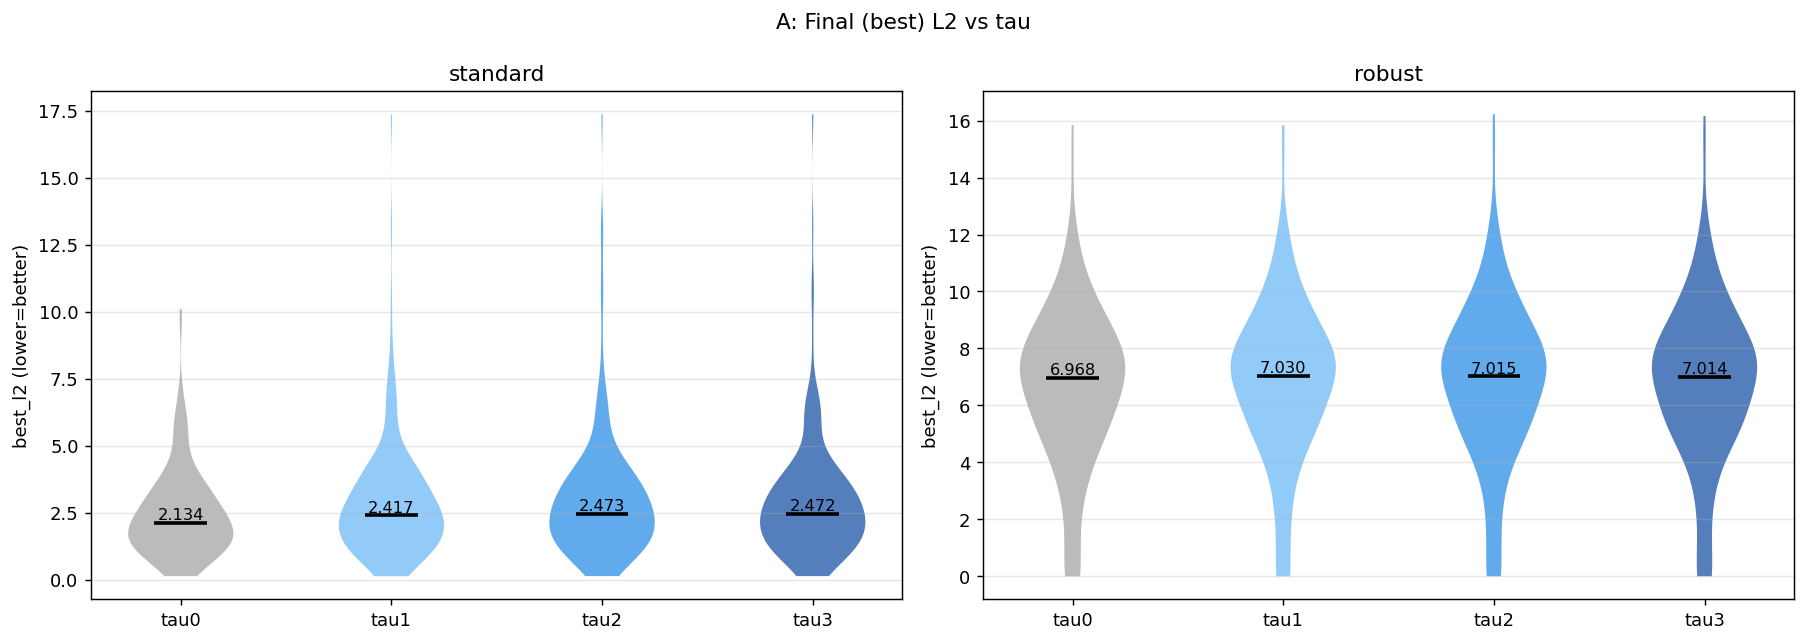

In [3]:
display(Image(f'{OUT}/A_final_l2.png'))

`tau=0` (gray) is shifted clearly left (lower L2 = better) for both models,
and the gap *widens* going from standard to robust in relative terms despite
looking smaller in absolute L2 units.


## B: Convergence curves -- the early-risk / late-payoff pattern

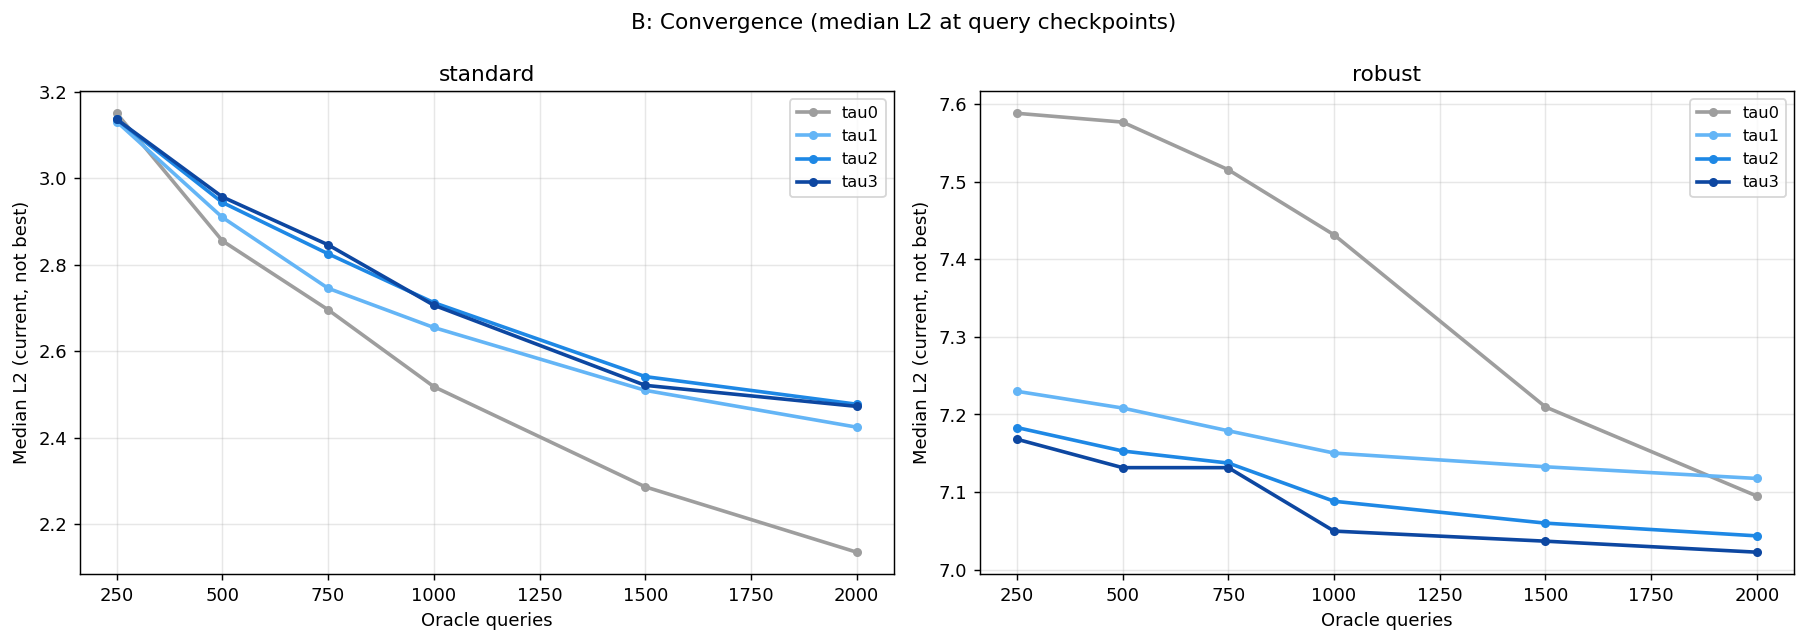

In [4]:
display(Image(f'{OUT}/B_convergence.png'))

This is the clearest picture of the tradeoff. For the **robust** model,
`tau=0` is actually the *worst* of the four conditions up through Q=1000-1250
-- it wanders into worse-than-`tau>=1` territory early on. But it keeps
improving while the `tau>=1` curves flatten out (they've run out of
generations), and by Q=2000 `tau=0` has overtaken all of them to finish
lowest.

For **standard**, `tau=0` is ahead from Q=500 onward and the gap widens
monotonically to the end.

This is exactly the "go in the wrong direction now, benefit later" pattern
hypothesized: tolerating regressions costs L2 *temporarily* but buys more
generations, and more generations is worth more than avoiding any single
regression.


## C: Regression rates -- proposed (pre-backtrack) vs net (post-backtrack)

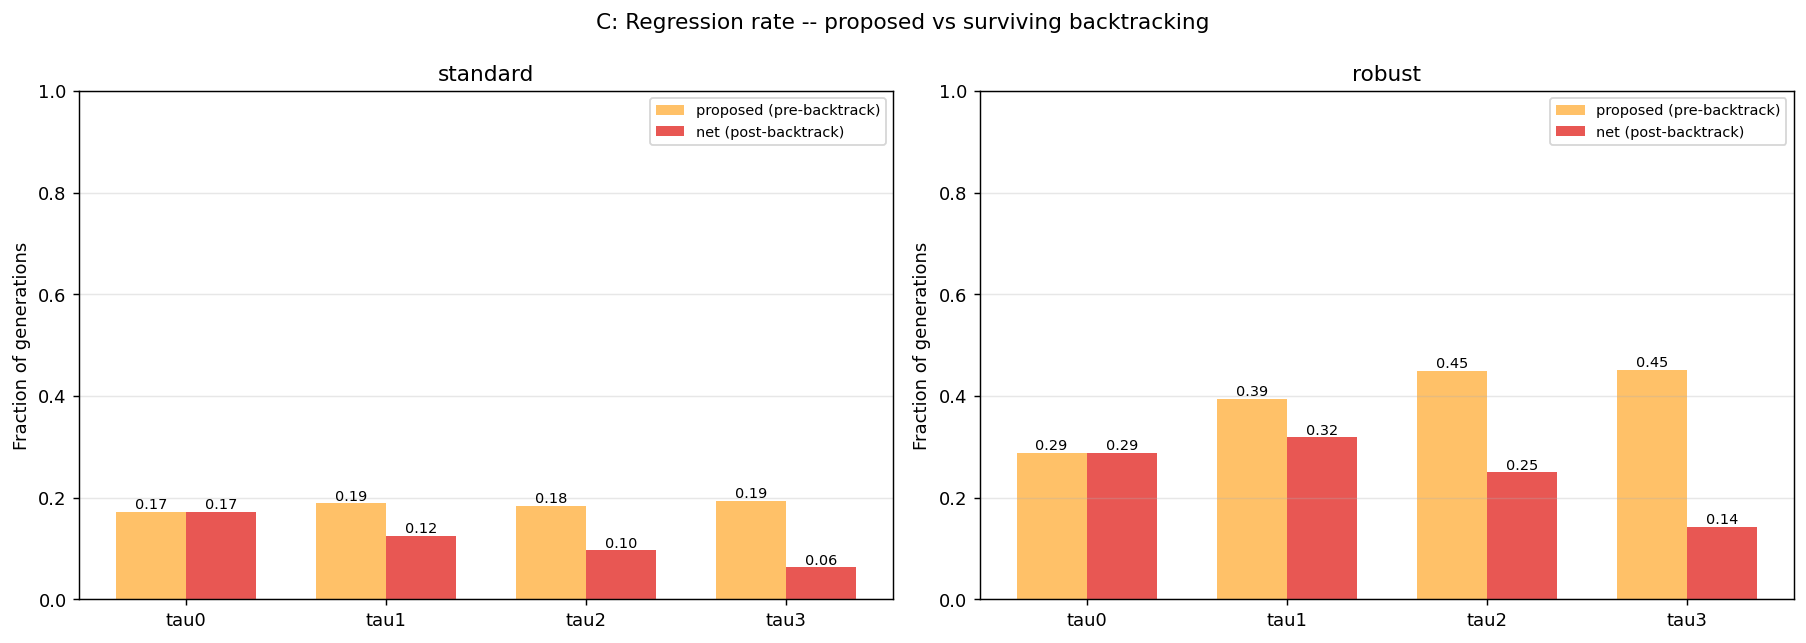

In [5]:
display(Image(f'{OUT}/C_regression_rates.png'))

**Standard**: the *proposed* regression rate is roughly flat across `tau`
(~0.17-0.19), as expected (it's a property of the step proposal, not of
`tau`). The *net* rate (regressions that survive backtracking) drops as
designed: 0.17 -> 0.12 -> 0.10 -> 0.06. So `tau` *does* do what it's supposed
to do for standard -- yet final L2 is still worse than `tau=0`. Reducing net
regressions isn't free, and here it costs more than it gives back.

**Robust**: the *proposed* rate actually *increases* with `tau`
(0.29 -> 0.39 -> 0.45 -> 0.45) -- the opposite of "roughly constant". This is
a compounding effect: `xi = dist_to_orig / sqrt(t)` is largest in *early*
generations (small `t`), and early generations are inherently more
regression-prone (bigger steps). Because `tau>=1` burns queries on
backtracking, runs complete far fewer generations (12-18 vs 59) -- so the
*sample* of generations is dominated by these early, high-`xi`,
high-regression generations. Fewer generations -> higher average regression
rate -> more backtracking needed -> even fewer generations: a vicious cycle
that `tau=0` simply never enters.

To be precise: this is a **sampling-composition effect, not a deferral**.
`tau` plays no role in the proposal itself -- the per-generation regression
probability as a function of `t` is the same regardless of `tau`. What
changes is *which* generations (which `t`) actually get sampled into the
average, because `tau` changes how many queries each generation costs and
therefore how many (and which) generations fit in the budget. Standard's
generation count shrinks mildly (57->44, ~23%) so its sample composition
barely shifts; robust's collapses (59->12, ~80%) so its sample becomes almost
entirely the high-`xi` early regime.


## D: Of regressions that survive backtracking, how many recover later anyway?

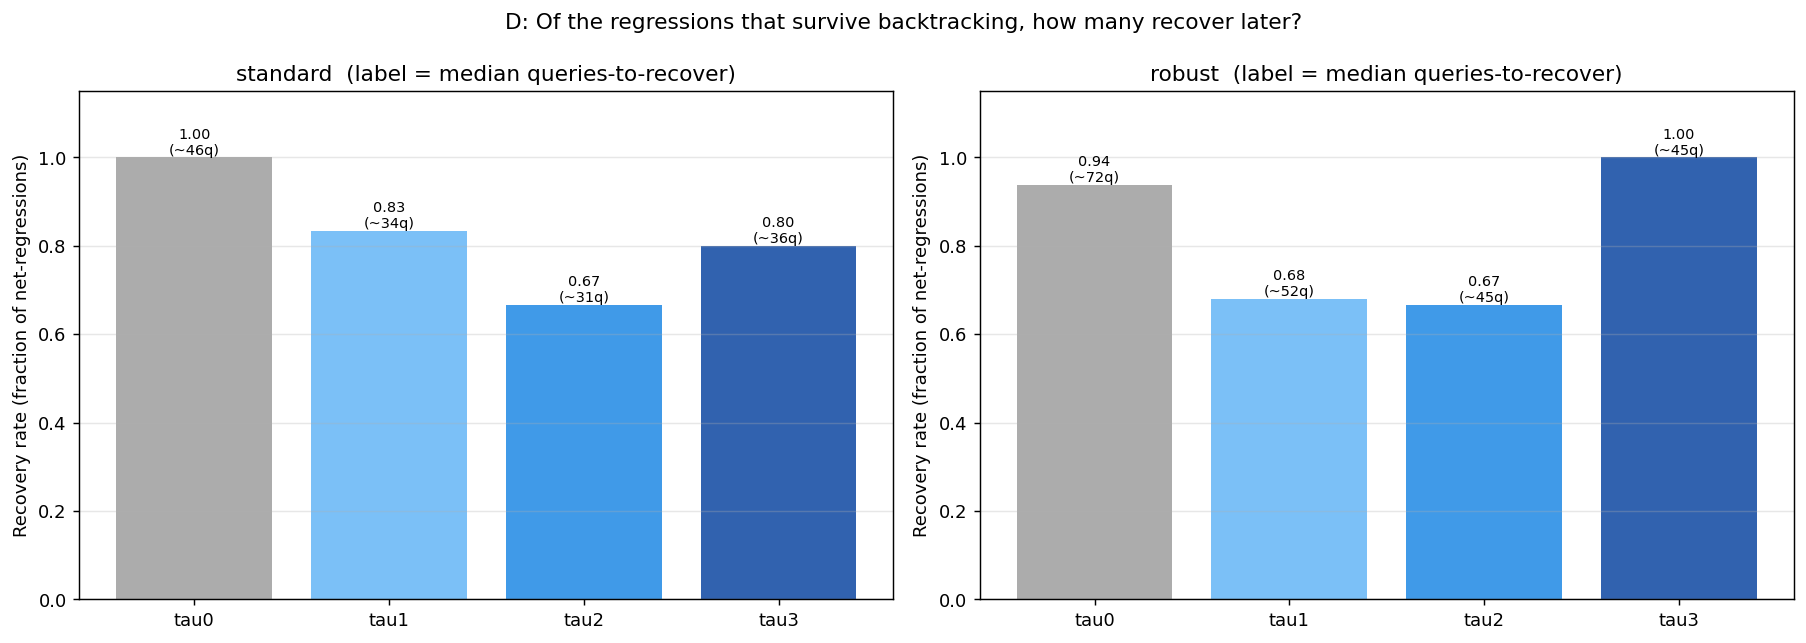

In [6]:
display(Image(f'{OUT}/D_recovery.png'))

At `tau=0`, 94-100% of "net regressions" (every proposed regression, since
nothing is backtracked) recover on their own within a handful of generations
(median ~45-72 extra queries) -- L2 drops back to at least where it was
before the regression, *without spending any dedicated recovery queries*.
This is the empirical basis for "most regressions self-heal": CMA-ES's own
mean-shift + covariance update routinely walks back out of a temporarily
worse region.

At `tau=0`, `net_regress_rate == regress_rate` exactly (nothing is filtered
by backtracking), so the "net regression" bucket contains *everything* --
including lots of trivial, tiny overshoots that almost always self-correct
within a generation or two. That's why its recovery rate is ~1.0.

At `tau>=1`, backtracking has already removed the easy cases from that
bucket by definition (anything backtracking *could* fix is no longer counted
as a "net regression"). What's left is a smaller, harder-skewed residual:
regressions that survived `tau` backtrack attempts. That residual subset is
less likely to self-heal too -- hence the lower recovery rates at `tau=1/2`
(0.83/0.67 standard, 0.68/0.67 robust) than `tau=0`. The `median_recov_q`
differences are a secondary effect of the same filtering and are less
central to the story than the rate itself.


## E: Backtracking cost vs generations completed

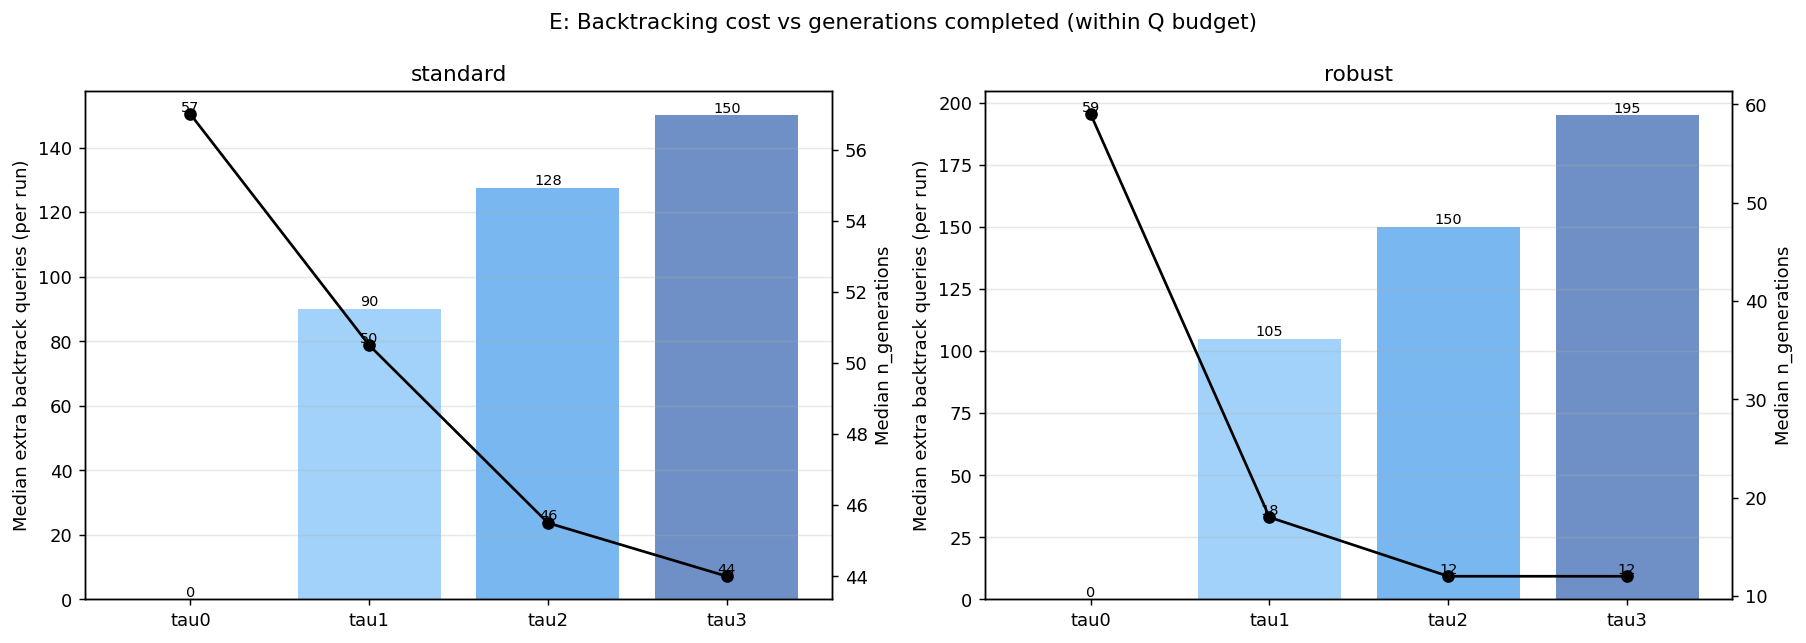

In [7]:
display(Image(f'{OUT}/E_backtrack_cost.png'))

The *direct* backtrack query cost (median 90-195 extra queries/run, i.e.
~5-10% of the 2000-query budget) looks modest on its own. But the
*generations* axis shows the real damage for robust: 59 -> 18 -> 12 -> 12.
A ~10% direct query tax triggers a much larger generation collapse via the
feedback loop described in C -- the cost of `tau>=1` is not just the
backtrack queries themselves, it's the knock-on reduction in search
iterations.

Note the collapse is **front-loaded and non-linear**: almost the entire drop
happens going from `tau=0` to `tau=1` (59 -> 18), with `tau=2/3` only adding a
little more (-> 12). A ~10% per-generation cost does not translate into a
proportional ~10% fewer generations -- it triggers the feedback loop from C
almost as soon as it's switched on.


## Conclusion

`tau=0` (no backtracking) is the better default for both models under the
shared config -- it gives the best final L2, the most generations completed,
and costs nothing extra. This empirically confirms the discussion that
preceded this study: non-elitist CMA-ES's regressions are largely
self-correcting, and `tau`'s reactive "fix the regression now" approach
trades a small direct query cost for a much larger loss in search iterations
-- worst of all for the robust model, where it creates a feedback loop that
starves the run down to ~12-18 generations instead of ~59.

This doesn't mean "regressions don't matter" -- it means the *current*
mechanism for handling them (per-generation reactive backtracking) is net
negative, and any future fix should not cost queries per occurrence (e.g.
proactive step-size adaptation informed by the trajectory's history, as
discussed separately).

**Recommendation**: adopt `tau=0` in the shared config going forward,
*conditional on the caveat in the addendum below*.


## Addendum: an "anytime algorithm" caveat for the robust model

The `tau=0` recommendation above relies entirely on the `best_l2` fix --
reporting the running minimum L2 seen at any point during the search, not
the L2 of wherever the search *currently* is at the end of the budget. The
two can differ a lot, especially for the robust model under `tau=0`.


In [8]:
SNAP_QS = [250, 500, 750, 1000, 1500, 2000]

def l2_at_q(traj, q, init_l2):
    val = init_l2
    for qq, l2 in traj:
        if qq <= q:
            val = l2
        else:
            break
    return val

print('Median CURRENT L2 at each query checkpoint (robust):')
for cname in COND_ORDER:
    sub = ok[(ok.model=='robust') & (ok.condition==cname)]
    meds = []
    for sq in SNAP_QS:
        curve = []
        for _, row in sub.iterrows():
            key = (cname, 'robust', int(row['image_idx']))
            curve.append(l2_at_q(all_traj.get(key, []), sq, row['init_l2']))
        meds.append(np.median(curve))
    print(f'  {cname}: ' + '  '.join(f'Q{sq}={m:.3f}' for sq, m in zip(SNAP_QS, meds)))


Median CURRENT L2 at each query checkpoint (robust):
  tau0: Q250=7.588  Q500=7.577  Q750=7.515  Q1000=7.431  Q1500=7.210  Q2000=7.095
  tau1: Q250=7.230  Q500=7.208  Q750=7.179  Q1000=7.150  Q1500=7.133  Q2000=7.118
  tau2: Q250=7.183  Q500=7.153  Q750=7.137  Q1000=7.088  Q1500=7.060  Q2000=7.044
  tau3: Q250=7.168  Q500=7.132  Q750=7.132  Q1000=7.050  Q1500=7.037  Q2000=7.023


```
robust, median CURRENT L2 at each checkpoint:
        Q250    Q500    Q750    Q1000   Q1500   Q2000
tau0:   7.588   7.577   7.515   7.431   7.210   7.095
tau2:   7.183   7.153   7.137   7.088   7.060   7.044
tau3:   7.168   7.132   7.132   7.050   7.037   7.023
```

At **Q2000**, `tau=0`'s *current* position (7.095) is still *worse* than
`tau=2` (7.044) and `tau=3` (7.023) -- even though `tau=0`'s *best-ever*
(`best_l2`=6.9685) beats both (7.0155 / 7.0141).

So for the robust model, `tau=0` produces a **high-variance trajectory**: it
dips to an excellent minimum (6.97) at some point mid-run, then wanders back
*up* to 7.095 by the end. `tau=2/3` produce **smoother, lower-variance
trajectories** that stay close to their own (worse) minimum throughout.

**Implication**: `tau=0`'s win depends on bookkeeping the running-best
(`best_l2`) -- which is free (no extra queries) and which we now always do.
If a deployment *can* track best-so-far and return that, `tau=0` is the
clear choice. But if it can only report/use the *current* adversarial image
(e.g. an anytime attack that might be cut off and must hand back its current
working example, not a remembered snapshot), `tau=0` is actually the *worst*
option for the robust model -- both early (Q250: 7.588 vs 7.17-7.18) and even
at the full Q2000 budget (7.095 vs 7.02-7.04).

**Revised recommendation**: adopt `tau=0` + best-so-far bookkeeping as the
default (cheap, strictly better when budget is known and bookkeeping is
possible). If a use case cannot track best-so-far and needs the *current*
point to be good at all times -- particularly against robust models --
`tau>=2` is the safer choice, trading a worse ceiling for a much more stable,
closer-to-monotonic trajectory.
